In [ ]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.20.0


In [ ]:

df = pd.read_csv('Bitcoin3.csv')

print(df.shape)
df.head()


(53150, 7)


,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
0,2017-09-21 09:00:00.000,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
1,2017-09-21 10:00:00.000,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2,2017-09-21 11:00:00.000,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
3,2017-09-21 12:00:00.000,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
4,2017-09-21 13:00:00.000,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53150 entries, 0 to 53149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         53150 non-null  object 
 1   Close        53150 non-null  float64
 2   Volume USDT  53150 non-null  float64
 3   RSI          53150 non-null  float64
 4   MACD_Hist    53150 non-null  float64
 5   ATR          53150 non-null  float64
 6   KAMAO        53150 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.8+ MB


In [ ]:

df['Date'] = pd.to_datetime(df['Date'], format='mixed')

df = df.sort_values('Date').reset_index(drop=True)

df.head()


,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
0,2017-09-21 09:00:00,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
1,2017-09-21 10:00:00,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2,2017-09-21 11:00:00,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
3,2017-09-21 12:00:00,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
4,2017-09-21 13:00:00,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


In [ ]:
df.isnull().sum()


,0
Date,0
Close,0
Volume USDT,0
RSI,0
MACD_Hist,0
ATR,0
KAMAO,0



## Feature Engineering - Rolling Statistic




In [ ]:
df['Rolling_Mean_24'] = df['Close'].rolling(window=24).mean()
df['Rolling_STD_24'] = df['Close'].rolling(window=24).std()

df.dropna(inplace=True)

df.head()


,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO,Rolling_Mean_24,Rolling_STD_24
23,2017-09-22 08:00:00,3647.70,98670.562044,48.507646,-49.453354,86.625836,0.015093,3709.506667,91.112560
24,2017-09-22 09:00:00,3606.95,107162.792190,48.366751,-49.745629,86.528735,-0.453320,3698.962917,87.510496
25,2017-09-22 10:00:00,3572.85,150926.427424,48.249126,-50.150669,86.412221,-0.843745,3686.520000,83.030244
26,2017-09-22 11:00:00,3539.97,190043.740129,48.135914,-50.661754,86.392482,-1.217532,3672.979167,79.071138
27,2017-09-22 12:00:00,3592.12,127074.058322,48.328786,-50.963345,86.373427,-0.610674,3661.897500,70.133487



## Exploratory Data Analysis


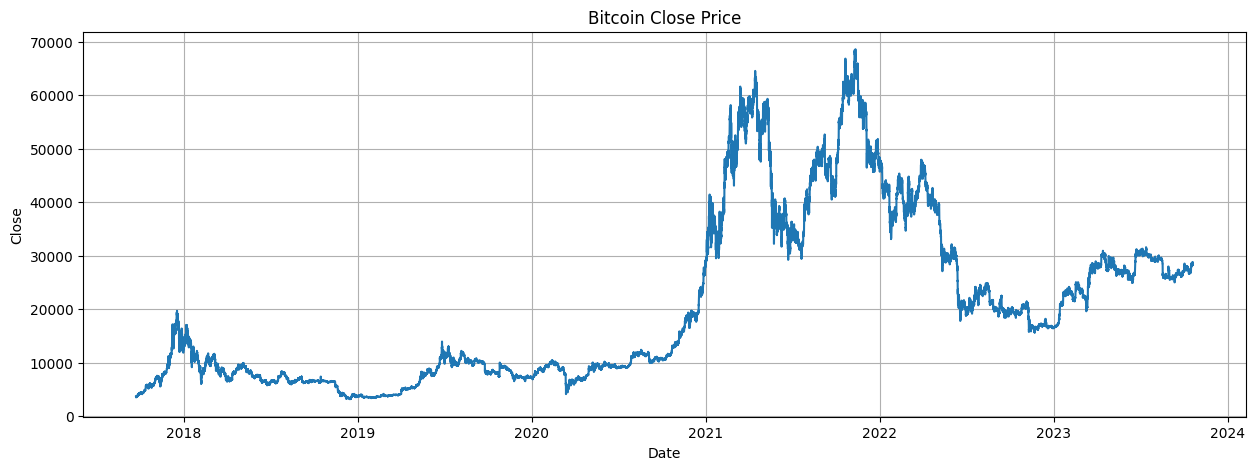

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['Date'], df['Close'])
plt.title('Bitcoin Close Price')
plt.xlabel('Date')
plt.ylabel('Close')
plt.grid(True)
plt.show()


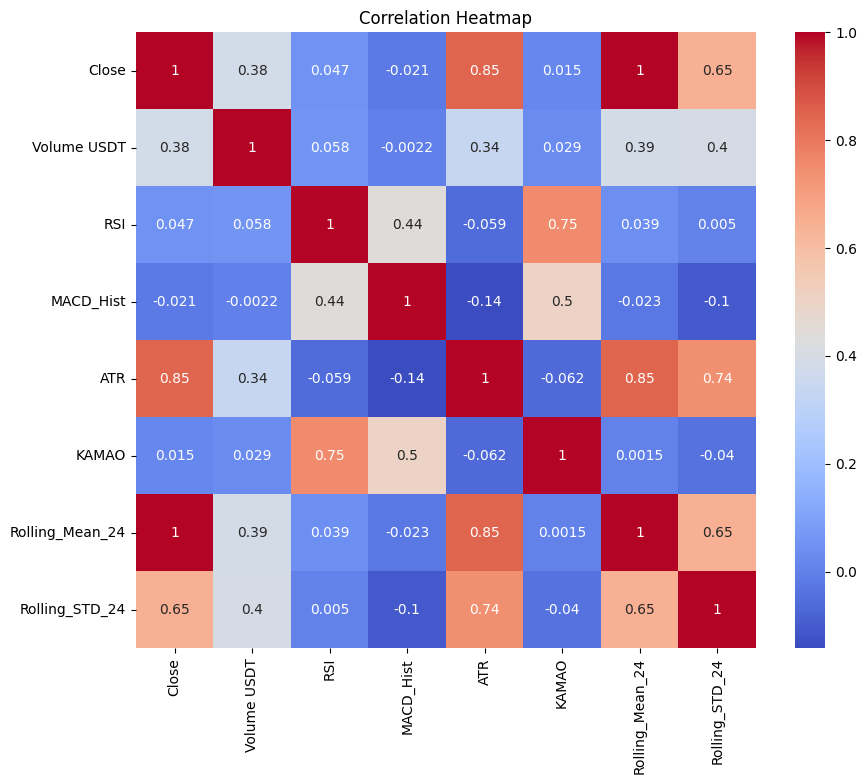

In [ ]:
selected_features = [
    'Close',
    'Volume USDT',
    'RSI',
    'MACD_Hist',
    'ATR',
    'KAMAO',
    'Rolling_Mean_24',
    'Rolling_STD_24'
]

corr = df[selected_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



## Penentuan Window Size dengan ACF & PACF


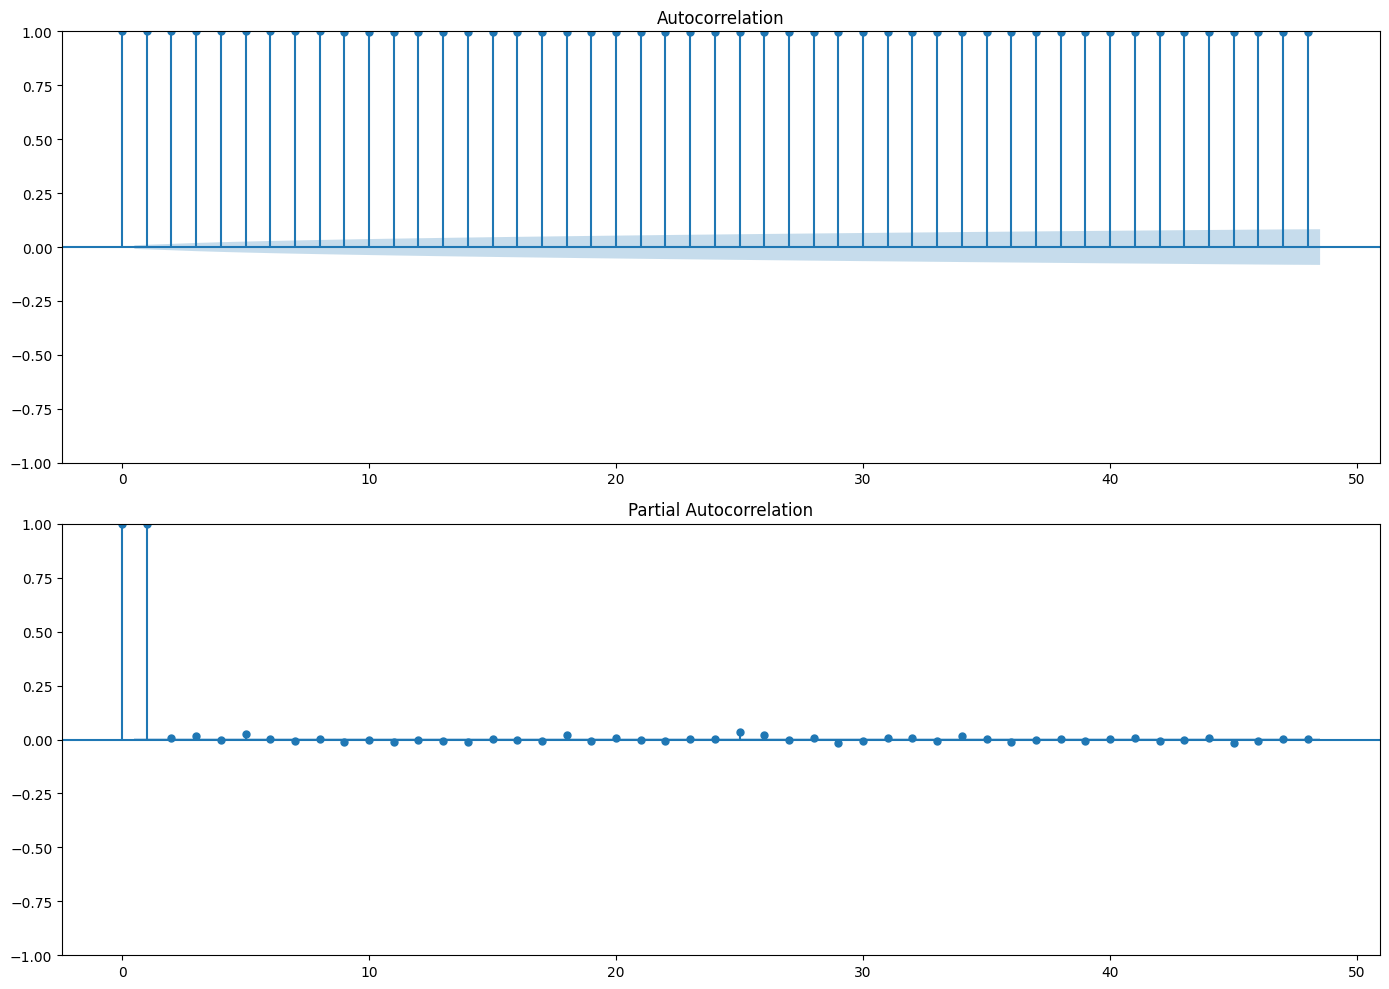

In [ ]:

fig, ax = plt.subplots(2,1, figsize=(14,10))

plot_acf(df['Close'], lags=48, ax=ax[0])
plot_pacf(df['Close'], lags=48, ax=ax[1])

plt.tight_layout()
plt.show()



Berdasarkan hasil ACF dan PACF, digunakan:
- Window size = 24
- Horizon forecasting = 24 langkah ke depan


In [ ]:
features = [
    'Close',
    'Volume USDT',
    'RSI',
    'MACD_Hist',
    'ATR',
    'KAMAO',
    'Rolling_Mean_24',
    'Rolling_STD_24'
]

target = 'Close'

data = df[features].copy()

data.head()


,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO,Rolling_Mean_24,Rolling_STD_24
23,3647.70,98670.562044,48.507646,-49.453354,86.625836,0.015093,3709.506667,91.112560
24,3606.95,107162.792190,48.366751,-49.745629,86.528735,-0.453320,3698.962917,87.510496
25,3572.85,150926.427424,48.249126,-50.150669,86.412221,-0.843745,3686.520000,83.030244
26,3539.97,190043.740129,48.135914,-50.661754,86.392482,-1.217532,3672.979167,79.071138
27,3592.12,127074.058322,48.328786,-50.963345,86.373427,-0.610674,3661.897500,70.133487



## Train Test Split

Normalisasi dilakukan SETELAH split untuk menghindari data leakage.


In [ ]:
train_size = int(len(data) * 0.8)

train_df = data.iloc[:train_size]
test_df = data.iloc[train_size:]

print("Train:", train_df.shape)
print("Test :", test_df.shape)


Train: (42501, 8)
Test : (10626, 8)


In [ ]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

print(train_scaled.shape)
print(test_scaled.shape)


(42501, 8)
(10626, 8)


In [ ]:
WINDOW_SIZE = 24
HORIZON = 24
N_FEATURES = len(features)

print(N_FEATURES)


8


In [ ]:

def create_sequences_multistep(data, window_size, horizon):
    X, y = [], []

    for i in range(len(data) - window_size - horizon):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon, 0])

    return np.array(X), np.array(y)

X_train, y_train = create_sequences_multistep(
    train_scaled,
    WINDOW_SIZE,
    HORIZON
)

X_test, y_test = create_sequences_multistep(
    test_scaled,
    WINDOW_SIZE,
    HORIZON
)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(42453, 24, 8)
(42453, 24)
(10578, 24, 8)
(10578, 24)



# Baseline Model - LSTM


In [ ]:
class CustomDense(layers.Layer):

    def __init__(self, units):
        super(CustomDense, self).__init__()
        self.units = units

    def build(self, input_shape):

        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='random_normal',
            trainable=True
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):
        return tf.matmul(inputs, self.w) + self.b


In [ ]:
baseline_model = tf.keras.Sequential([
    layers.Input(shape=(WINDOW_SIZE, N_FEATURES)),
    layers.LSTM(64),
    CustomDense(HORIZON)
])

baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense (CustomDense)      │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,248 (79.09 KB)

 Trainable params: 20,248 (79.09 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
loss_fn = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)



# Custom Training dengan GradientTape


In [ ]:
BATCH_SIZE = 64

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
).batch(BATCH_SIZE)


In [ ]:
EPOCHS = 10

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    epoch_train_loss = []

    for x_batch, y_batch in train_dataset:

        with tf.GradientTape() as tape:

            predictions = baseline_model(x_batch, training=True)

            loss = loss_fn(y_batch, predictions)

        gradients = tape.gradient(
            loss,
            baseline_model.trainable_variables
        )

        optimizer.apply_gradients(
            zip(gradients, baseline_model.trainable_variables)
        )

        epoch_train_loss.append(loss.numpy())

    train_loss = np.mean(epoch_train_loss)

    # VALIDATION
    epoch_val_loss = []

    for x_val, y_val in val_dataset:

        val_pred = baseline_model(x_val, training=False)

        val_loss = loss_fn(y_val, val_pred)

        epoch_val_loss.append(val_loss.numpy())

    val_loss_final = np.mean(epoch_val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss_final)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"loss: {train_loss:.5f} | "
        f"val_loss: {val_loss_final:.5f}"
    )


Epoch 1/10 | loss: 0.00202 | val_loss: 0.00734
Epoch 2/10 | loss: 0.00276 | val_loss: 0.00632
Epoch 3/10 | loss: 0.00300 | val_loss: 0.00676
Epoch 4/10 | loss: 0.00304 | val_loss: 0.00705
Epoch 5/10 | loss: 0.00326 | val_loss: 0.00670
Epoch 6/10 | loss: 0.00352 | val_loss: 0.00562
Epoch 7/10 | loss: 0.00355 | val_loss: 0.00458
Epoch 8/10 | loss: 0.00344 | val_loss: 0.00343
Epoch 9/10 | loss: 0.00316 | val_loss: 0.00242
Epoch 10/10 | loss: 0.00261 | val_loss: 0.00170


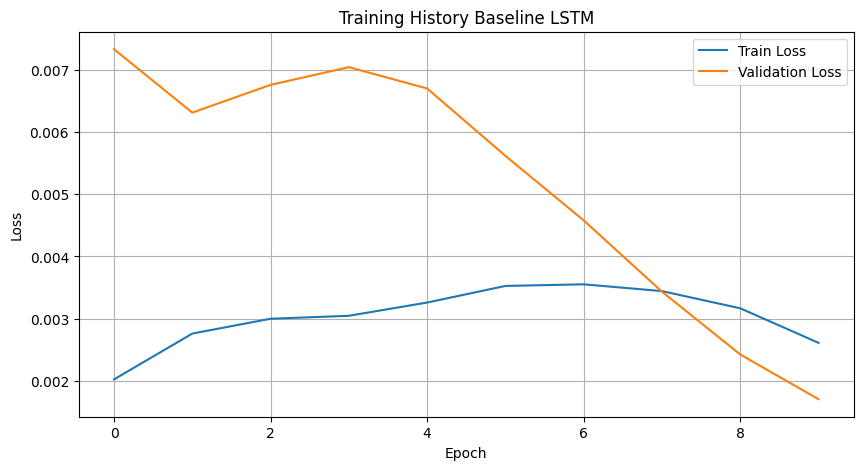

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.title('Training History Baseline LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)
plt.show()



# Seq2Seq LSTM dengan Teacher Forcing


In [ ]:

decoder_input_train = np.zeros((len(y_train), HORIZON, 1))
decoder_input_test = np.zeros((len(y_test), HORIZON, 1))

decoder_input_train[:,1:,0] = y_train[:,:-1]
decoder_input_test[:,1:,0] = y_test[:,:-1]

print(decoder_input_train.shape)


(42453, 24, 1)


In [ ]:
encoder_inputs = layers.Input(
    shape=(WINDOW_SIZE, N_FEATURES)
)

encoder_lstm = layers.LSTM(
    64,
    return_state=True
)

encoder_outputs, state_h, state_c = encoder_lstm(
    encoder_inputs
)

encoder_states = [state_h, state_c]



decoder_inputs = layers.Input(
    shape=(HORIZON, 1)
)

decoder_lstm = layers.LSTM(
    64,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_inputs,
    initial_state=encoder_states
)

decoder_outputs = CustomDense(1)(decoder_outputs)

seq2seq_model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

seq2seq_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 24, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 64),      │     18,688 │ input_layer_1[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 24, 64),  │     16,896 │ input_layer_2[0]… │
│                     │ (None, 64),       │            │ lstm_1[0][1],     │
│                     │ (None, 64)]       │            │ lstm_1[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_1      │ (None, 24, 1)     │         65 │ lstm_2[0][0]      │
│ (CustomDense)       │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,649 (139.25 KB)

 Trainable params: 35,649 (139.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer_seq = tf.keras.optimizers.Adam(0.001)
loss_fn_seq = tf.keras.losses.MeanSquaredError()


In [ ]:

train_dataset_seq = tf.data.Dataset.from_tensor_slices(
    (
        (X_train, decoder_input_train),
        y_train.reshape(-1, HORIZON, 1)
    )
).batch(BATCH_SIZE)

val_dataset_seq = tf.data.Dataset.from_tensor_slices(
    (
        (X_test, decoder_input_test),
        y_test.reshape(-1, HORIZON, 1)
    )
).batch(BATCH_SIZE)


In [ ]:

EPOCHS_SEQ = 10

train_losses_seq = []
val_losses_seq = []

for epoch in range(EPOCHS_SEQ):

    batch_losses = []

    for (encoder_x, decoder_x), y_batch in train_dataset_seq:

        with tf.GradientTape() as tape:

            predictions = seq2seq_model(
                [encoder_x, decoder_x],
                training=True
            )

            loss = loss_fn_seq(y_batch, predictions)

        gradients = tape.gradient(
            loss,
            seq2seq_model.trainable_variables
        )

        optimizer_seq.apply_gradients(
            zip(gradients, seq2seq_model.trainable_variables)
        )

        batch_losses.append(loss.numpy())

    train_loss = np.mean(batch_losses)

    val_batch_loss = []

    for (encoder_val, decoder_val), y_val in val_dataset_seq:

        val_pred = seq2seq_model(
            [encoder_val, decoder_val],
            training=False
        )

        val_loss = loss_fn_seq(y_val, val_pred)

        val_batch_loss.append(val_loss.numpy())

    val_loss_final = np.mean(val_batch_loss)

    train_losses_seq.append(train_loss)
    val_losses_seq.append(val_loss_final)

    print(
        f"Epoch {epoch+1}/{EPOCHS_SEQ} | "
        f"loss: {train_loss:.5f} | "
        f"val_loss: {val_loss_final:.5f}"
    )


Epoch 1/10 | loss: 0.00135 | val_loss: 0.00457
Epoch 2/10 | loss: 0.00198 | val_loss: 0.00437
Epoch 3/10 | loss: 0.00209 | val_loss: 0.00493
Epoch 4/10 | loss: 0.00238 | val_loss: 0.00453
Epoch 5/10 | loss: 0.00256 | val_loss: 0.00396
Epoch 6/10 | loss: 0.00263 | val_loss: 0.00340
Epoch 7/10 | loss: 0.00253 | val_loss: 0.00292
Epoch 8/10 | loss: 0.00251 | val_loss: 0.00227
Epoch 9/10 | loss: 0.00231 | val_loss: 0.00189
Epoch 10/10 | loss: 0.00195 | val_loss: 0.00137



# Inference Autoregressive Seq2Seq


In [ ]:

def autoregressive_forecast(model, encoder_input):

    decoder_input = np.zeros((1, HORIZON, 1))

    predictions = []

    for step in range(HORIZON):

        pred = model.predict(
            [encoder_input, decoder_input],
            verbose=0
        )

        next_value = pred[0, step, 0]

        predictions.append(next_value)

        if step + 1 < HORIZON:
            decoder_input[0, step + 1, 0] = next_value

    return np.array(predictions)


In [ ]:
baseline_pred = baseline_model.predict(X_test)

baseline_pred.shape


331/331 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


(10578, 24)

In [ ]:
encoder_inf_model = Model(encoder_inputs, encoder_states)

decoder_state_input_h = layers.Input(shape=(64,))
decoder_state_input_c = layers.Input(shape=(64,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_input_single_step = layers.Input(shape=(1, 1)) # Input untuk satu langkah waktu

decoder_outputs_inf, state_h_inf, state_c_inf = decoder_lstm(
    decoder_input_single_step, initial_state=decoder_states_inputs
)
decoder_states_inf = [state_h_inf, state_c_inf]

decoder_outputs_inf = CustomDense(1)(decoder_outputs_inf) # Aplikasikan layer CustomDense

decoder_inf_model = Model(
    [decoder_input_single_step] + decoder_states_inputs,
    [decoder_outputs_inf] + decoder_states_inf
)

print("Encoder Inference Model Summary:")
encoder_inf_model.summary()
print("\nDecoder Inference Model Summary:")
decoder_inf_model.summary()

Encoder Inference Model Summary:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 24, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ [(None, 64), (None,    │        18,688 │
│                                 │ 64), (None, 64)]       │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,688 (73.00 KB)

 Trainable params: 18,688 (73.00 KB)

...

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 1, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 1, 64),   │     16,896 │ input_layer_5[0]… │
│                     │ (None, 64),       │            │ input_layer_3[0]… │
│                     │ (None, 64)]       │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_2      │ (None, 1, 1)      │         65 │ lstm_2[1][0]      │
│ (CustomDense)       │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
initial_encoder_states = encoder_inf_model.predict(X_test, verbose=0)

seq_preds_batch = np.zeros((X_test.shape[0], HORIZON))

decoder_input_batch = np.zeros((X_test.shape[0], 1, 1))

states_h, states_c = initial_encoder_states

for t in range(HORIZON):
    output_tokens, states_h, states_c = decoder_inf_model.predict(
        [decoder_input_batch, states_h, states_c],
        verbose=0
    )

    seq_preds_batch[:, t] = output_tokens[:, 0, 0]

    decoder_input_batch = output_tokens

print(f"Shape prediksi Seq2Seq secara batch: {seq_preds_batch.shape}")
seq_preds = seq_preds_batch

Shape prediksi Seq2Seq secara batch: (10578, 24)


In [ ]:
def inverse_close_only(values):

    dummy = np.zeros((len(values), N_FEATURES))

    dummy[:,0] = values

    inversed = scaler.inverse_transform(dummy)

    return inversed[:,0]


In [ ]:

actual = inverse_close_only(y_test[0])

baseline_result = inverse_close_only(
    baseline_pred[0]
)

seq_result = inverse_close_only(
    seq_preds[0]
)


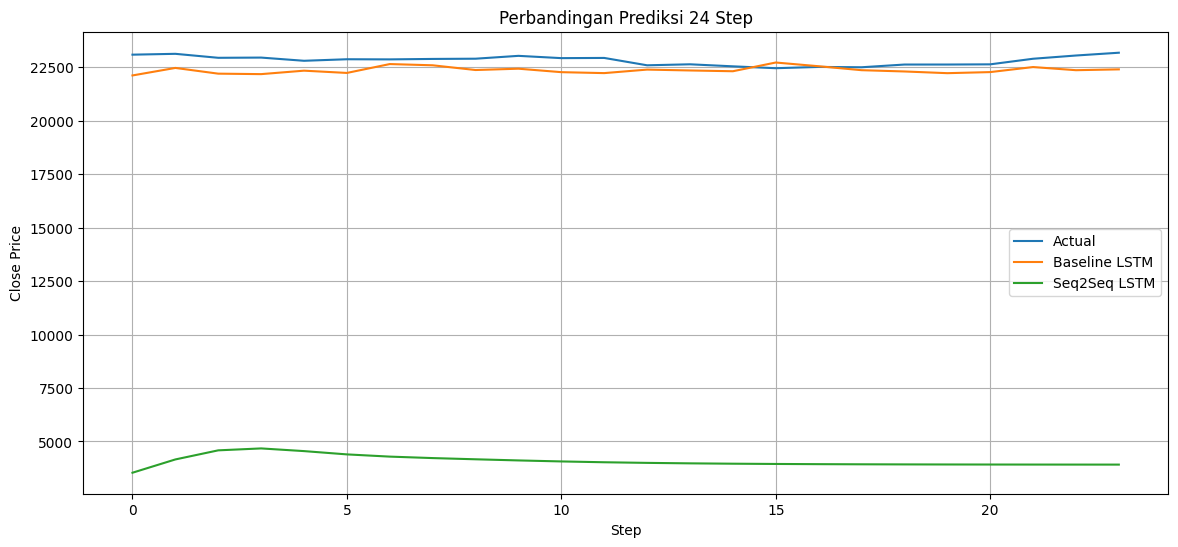

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(actual, label='Actual')
plt.plot(baseline_result, label='Baseline LSTM')
plt.plot(seq_result, label='Seq2Seq LSTM')

plt.title('Perbandingan Prediksi 24 Step')
plt.xlabel('Step')
plt.ylabel('Close Price')

plt.legend()
plt.grid(True)
plt.show()


In [ ]:
comparison_df = pd.DataFrame({
    'Actual': actual,
    'Baseline_LSTM': baseline_result,
    'Seq2Seq_LSTM': seq_result
})

comparison_df.head(24)


,Actual,Baseline_LSTM,Seq2Seq_LSTM
0,23084.45,22112.847034,3537.825879
1,23123.82,22464.135494,4158.736076
2,22937.73,22196.453235,4584.170048
3,22947.92,22174.406014,4673.947827
4,22798.24,22336.062227,4548.553158
5,22870.10,22230.096659,4394.888111
6,22863.83,22645.250073,4290.789320
7,22885.01,22587.526580,4222.449712
8,22895.80,22366.318873,4165.739229
9,23029.09,22428.373383,4112.701210


In [ ]:
mae_baseline = mean_absolute_error(
    actual,
    baseline_result
)

rmse_baseline = np.sqrt(
    mean_squared_error(
        actual,
        baseline_result
    )
)

mae_seq = mean_absolute_error(
    actual,
    seq_result
)

rmse_seq = np.sqrt(
    mean_squared_error(
        actual,
        seq_result
    )
)

print("=== BASELINE LSTM ===")
print("MAE :", mae_baseline)
print("RMSE:", rmse_baseline)

print("\n=== SEQ2SEQ LSTM ===")
print("MAE :", mae_seq)
print("RMSE:", rmse_seq)


=== BASELINE LSTM ===
MAE : 473.1948151679826
RMSE: 530.5317460951107

=== SEQ2SEQ LSTM ===
MAE : 18726.701023627134
RMSE: 18729.066989664487


In [38]:

# =========================
# SAVE MODEL
# =========================

baseline_model.save('baseline_lstm.keras')
seq2seq_model.save('seq2seq_lstm.keras')

print("Model berhasil disimpan!")


Model berhasil disimpan!
